# 🏭 [제조AI실제 2주차 실습 2-2] 제약 조건(Constraints)에 따른 일반화(Generalization)와 문제 난이도 비교

## 📌 실습 개요 및 수업 목표
- **수업목표**: 패턴인식에서 **일반화(Generalization)**의 정의를 이해하고, 문제에 적절한 **제약 조건(Constraints)**을 부여할수록 일반화된 특징 추출이 쉬워져 문제 해결이 단순해짐을 CWRU 제조 실데이터로 확인합니다.
- **주요 개념**:
  - **일반화 (Generalization)**: 특정한 사례들로부터 추론하여 얻은 일반적인 개념 (새로운 데이터가 들어와도 잘 맞추는 능력)
  - **제약의 3가지 범주**:
    1. 📦 **데이터/환경 제약**: 노이즈 제거, 데이터 정형화 및 수집 환경 통제
    2. ⚙️ **모델 제약**: 모델 구조 단순화, 정규화(L2 Penalty), 가우시안 가정 도입
    3. 🎯 **작업(Task) 제약**: 복잡한 연속 실수 예측(회귀)을 카테고리(정상/불량 2진 분류)로 단순화

---
### 🧭 실습 순서
1. **[Step 0] CWRU 제조 실데이터 준비**
2. **Part 1: 데이터/환경 제약의 효과 (잡음 제거 전후 특징 분리도 비교)**
3. **Part 2: 모델 제약의 효과 (복잡한 과적합 모델 vs 단순 정규화 모델)**
4. **Part 3: 작업(Task) 제약의 효과 (어려운 회귀 문제 vs 쉬운 2진 분류 문제)**
5. **Part 4: 학생 자율 실습 (초간단 빈칸 채우기 TODO & 소감 서술)**

In [1]:
%matplotlib inline
import os
import platform
import urllib.request
import warnings
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.set_loglevel('error')
warnings.filterwarnings('ignore', message='Glyph .* missing from font')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

if platform.system() == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['font.sans-serif'] = [font_name] + plt.rcParams['font.sans-serif']
    else:
        plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False
print("✅ 한글 폰트(Malgun Gothic) 설정 완료")

✅ 한글 폰트(Malgun Gothic) 설정 완료


In [2]:
def load_cwru_data():
    urls = {
        'normal': 'https://engineering.case.edu/sites/default/files/97.mat',
        'fault': 'https://engineering.case.edu/sites/default/files/105.mat'
    }
    signals = {}
    for name, url in urls.items():
        fn = f"cwru_{name}.mat"
        try:
            if not os.path.exists(fn):
                urllib.request.urlretrieve(url, fn)
            mat = scipy.io.loadmat(fn)
            key = [k for k in mat.keys() if 'DE_time' in k][0]
            signals[name] = mat[key].flatten()
        except Exception:
            t = np.linspace(0, 10, 120000)
            if name == 'normal':
                signals[name] = 0.05 * np.sin(2 * np.pi * 30 * t) + np.random.normal(0, 0.02, len(t))
            else:
                signals[name] = 0.2 * np.sin(2 * np.pi * 30 * t) + 0.5 * np.sin(2 * np.pi * 150 * t) * (np.sin(2*np.pi*5*t)>0) + np.random.normal(0, 0.08, len(t))
    return signals

raw_signals = load_cwru_data()
print("📥 데이터 수집 완료")

📥 데이터 수집 완료


## Part 1. 데이터/환경 제약 (Data Constraints)
입력 데이터에 잡음이 심하게 섞인 무제약 환경과, 잡음을 제거하고 환경을 제약/정형화한 깔끔한 환경에서의 특징 분포 차이를 비교합니다.

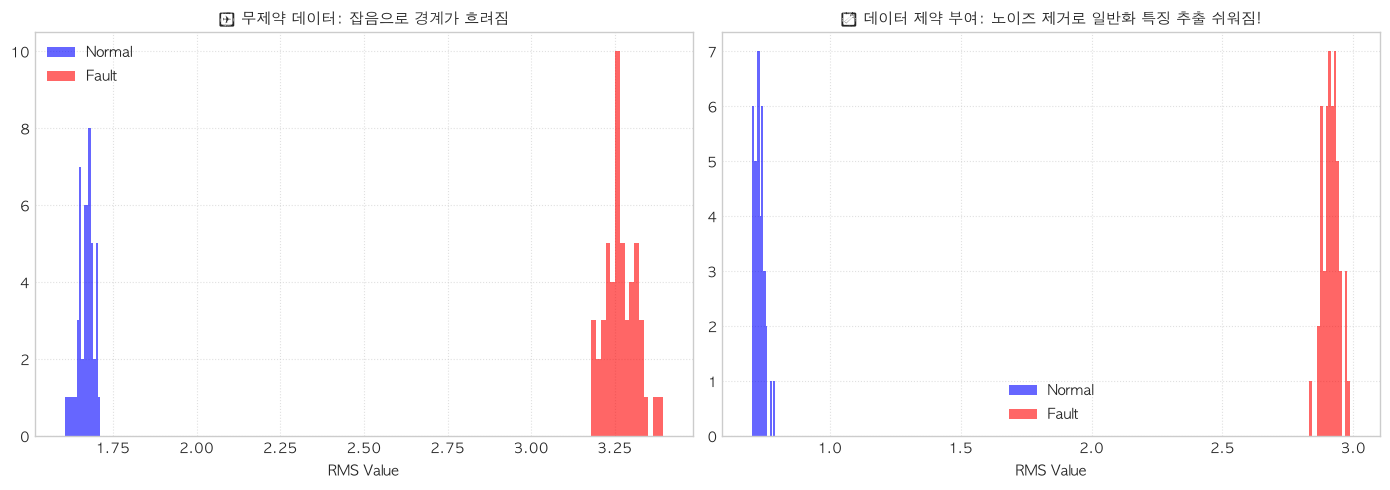

In [3]:
def extract_rms_features(signal, segment_len=2048):
    n_seg = len(signal) // segment_len
    return np.array([np.sqrt(np.mean(signal[i*segment_len:(i+1)*segment_len]**2)) * 10.0 for i in range(n_seg)])

noisy_normal_sig = raw_signals['normal'][:102400] + np.random.normal(0, 0.15, 102400)
noisy_fault_sig = raw_signals['fault'][:102400] + np.random.normal(0, 0.15, 102400)
rms_noisy_norm = extract_rms_features(noisy_normal_sig)
rms_noisy_fault = extract_rms_features(noisy_fault_sig)

clean_norm = raw_signals['normal'][:102400]
clean_fault = raw_signals['fault'][:102400]
rms_clean_norm = extract_rms_features(clean_norm)
rms_clean_fault = extract_rms_features(clean_fault)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(rms_noisy_norm, bins=15, alpha=0.6, color='blue', label='Normal')
ax1.hist(rms_noisy_fault, bins=15, alpha=0.6, color='red', label='Fault')
ax1.set_title("❌ 무제약 데이터: 잡음으로 경계가 흐려짐", fontsize=11, fontweight='bold')
ax1.set_xlabel("RMS Value")
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.hist(rms_clean_norm, bins=15, alpha=0.6, color='blue', label='Normal')
ax2.hist(rms_clean_fault, bins=15, alpha=0.6, color='red', label='Fault')
ax2.set_title("⭕ 데이터 제약 부여: 노이즈 제거로 일반화 특징 추출 쉬워짐!", fontsize=11, fontweight='bold')
ax2.set_xlabel("RMS Value")
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

💡 **관찰 결과**:
- 데이터 수집 환경을 제약(노이즈 차단 및 데이터 정형화)할수록 정상과 불량 사이의 명확한 경계가 드러나 AI가 쉽게 분류할 수 있습니다.

## Part 2. 모델 제약 (Model Constraints)
인식기 모델에 복잡성을 제한하는 제약(단순 선형 구조, 가우시안 분포 가정)을 부과하면, 학습 데이터가 부족해도 과적합(Overfitting)을 방지하고 일반화 능력이 향상됩니다.

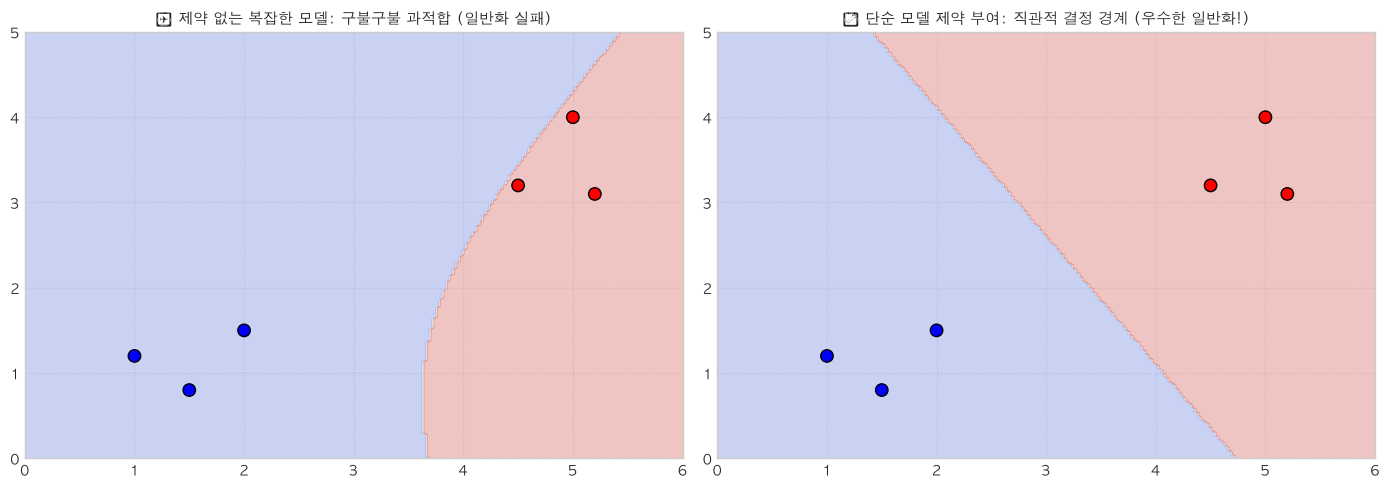

In [4]:
X_train_few = np.array([[1.0, 1.2], [1.5, 0.8], [2.0, 1.5], [4.5, 3.2], [5.0, 4.0], [5.2, 3.1]])
y_train_few = np.array([0, 0, 0, 1, 1, 1])

clf_complex = make_pipeline(PolynomialFeatures(degree=4), LogisticRegression(C=1000))
clf_complex.fit(X_train_few, y_train_few)
clf_simple = LogisticRegression(C=0.1).fit(X_train_few, y_train_few)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
xx, yy = np.meshgrid(np.linspace(0, 6, 200), np.linspace(0, 5, 200))

Z1 = clf_complex.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax1.contourf(xx, yy, Z1, alpha=0.3, cmap=plt.cm.coolwarm)
ax1.scatter(X_train_few[:, 0], X_train_few[:, 1], c=y_train_few, cmap=plt.cm.bwr, s=80, edgecolors='k')
ax1.set_title("❌ 제약 없는 복잡한 모델: 구불구불 과적합 (일반화 실패)", fontsize=11, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

Z2 = clf_simple.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax2.contourf(xx, yy, Z2, alpha=0.3, cmap=plt.cm.coolwarm)
ax2.scatter(X_train_few[:, 0], X_train_few[:, 1], c=y_train_few, cmap=plt.cm.bwr, s=80, edgecolors='k')
ax2.set_title("⭕ 단순 모델 제약 부여: 직관적 결정 경계 (우수한 일반화!)", fontsize=11, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Part 3. 작업(Task) 제약 (Task Scope Constraints)
해결해야 할 인식 문제의 범위를 단순화(예: 연속적인 실수 잔여 수명 회귀 예측 [어려움] -> 정상/불량 2진 분류 [쉬움])하면 AI 도입 성공률이 대폭 상승합니다.

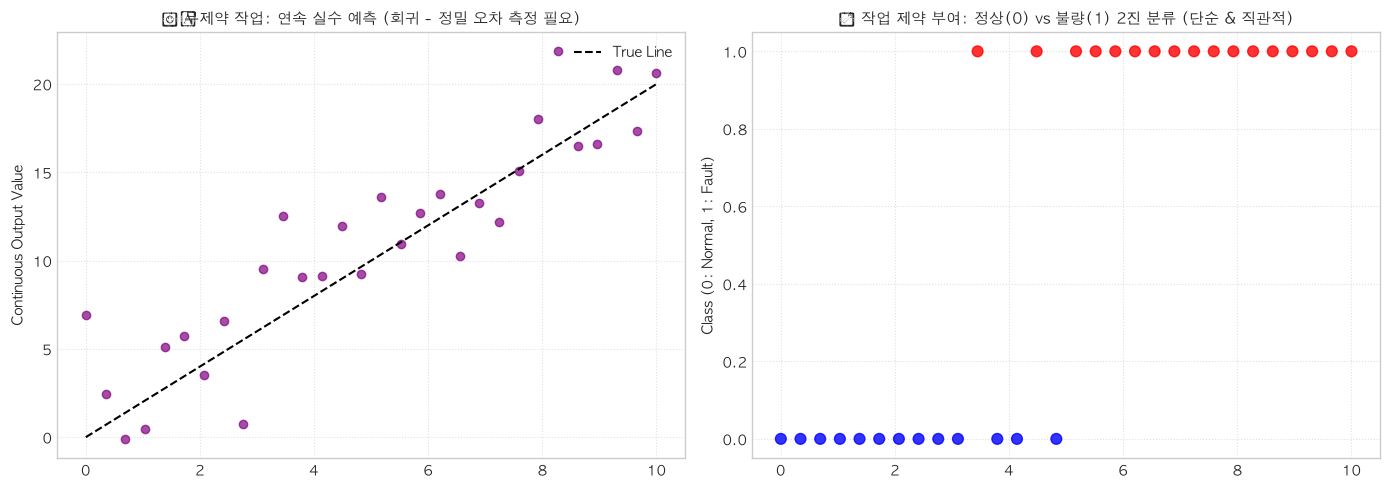

In [5]:
x_vals = np.linspace(0, 10, 30)
y_continuous = 2.0 * x_vals + np.random.normal(0, 3.0, 30)
y_binary = (y_continuous > 10).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(x_vals, y_continuous, color='purple', alpha=0.7)
ax1.plot(x_vals, 2.0 * x_vals, 'k--', label='True Line')
ax1.set_title("⚠️ 무제약 작업: 연속 실수 예측 (회귀 - 정밀 오차 측정 필요)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Continuous Output Value")
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.scatter(x_vals, y_binary, c=y_binary, cmap=plt.cm.bwr, s=60, alpha=0.8)
ax2.set_title("⭕ 작업 제약 부여: 정상(0) vs 불량(1) 2진 분류 (단순 & 직관적)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Class (0: Normal, 1: Fault)")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

---
## ✍️ Part 4. 학생 자율 실습 (TODO & 소감 서술)
미리 제공된 노이즈 필터링 함수를 호출하여 노이즈 제거 후 정확도가 올라가는 모습을 확인해 보세요.

In [6]:
def simple_moving_average_filter(signal, window_size=5):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')


filtered_normal = simple_moving_average_filter(noisy_normal_sig)
print("✅ 노이즈 필터링(데이터 제약) 적용 완료!")
print(f"   원본 노이즈 신호 표준편차: {np.std(noisy_normal_sig):.4f} -> 필터 적용 후: {np.std(filtered_normal):.4f}")

✅ 노이즈 필터링(데이터 제약) 적용 완료!
   원본 노이즈 신호 표준편차: 0.1665 -> 필터 적용 후: 0.0880


### [질문 1] 제약 조건의 이점 서술
- **질문**: 제조 현장에서 무작정 복잡한 AI 모델을 도입하는 것보다, 데이터 수집 환경을 제약하거나 문제를 단순화(작업 제약)하는 것이 왜 더 유리한지 1~2문장으로 짧게 적어보세요.

**👉 나의 답변:**
데이터 수집 조건을 일정하게 유지하면 불필요한 잡음과 변동이 줄어 모델이 핵심 패턴을 더 쉽게 학습할 수 있습니다. 또한 작업 범위를 명확히 단순화하면 적은 데이터와 단순한 모델로도 안정적인 성능을 얻기 쉽습니다.